In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [6]:
data = pd.read_csv('reddit_dead_internet_analysis_2026.csv')
print(data.columns)
columns_to_drop = ['subreddit', 'comment_id', 'bot_type_label', 'bot_probability', 'contains_links', 'avg_word_length']
data = data.drop(columns=columns_to_drop)
print(data.columns)
print(data)
print(data.columns.tolist())

Index(['comment_id', 'subreddit', 'account_age_days', 'user_karma',
       'reply_delay_seconds', 'sentiment_score', 'avg_word_length',
       'contains_links', 'is_bot_flag', 'bot_type_label', 'bot_probability'],
      dtype='object')
Index(['account_age_days', 'user_karma', 'reply_delay_seconds',
       'sentiment_score', 'is_bot_flag'],
      dtype='object')
     account_age_days  user_karma  reply_delay_seconds  sentiment_score  \
0                2264       34192                 1854            -0.60   
1                1654        2812                 1033             0.15   
2                2442       37109                 2703             0.35   
3                 168       32997                 2811            -0.74   
4                 801       25088                 1721            -0.96   
..                ...         ...                  ...              ...   
495                12       21283                    1            -0.21   
496              2178       43090   

In [7]:
y = data['is_bot_flag']
X = data.drop(columns=['is_bot_flag'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00        52
        True       1.00      1.00      1.00        48

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100

[[52  0]
 [ 0 48]]


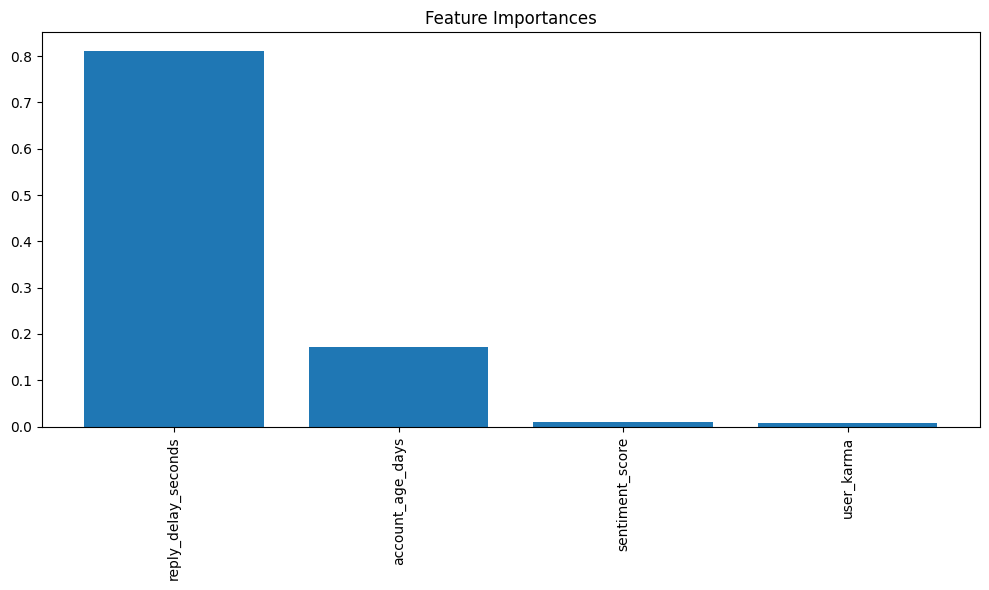

In [8]:
feature_importances = model.feature_importances_ 
features = X.columns
indices = np.argsort(feature_importances)[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X.shape[1]), feature_importances[indices], align="center")
plt.xticks(range(X.shape[1]), features[indices], rotation=90)
plt.tight_layout()
plt.show()

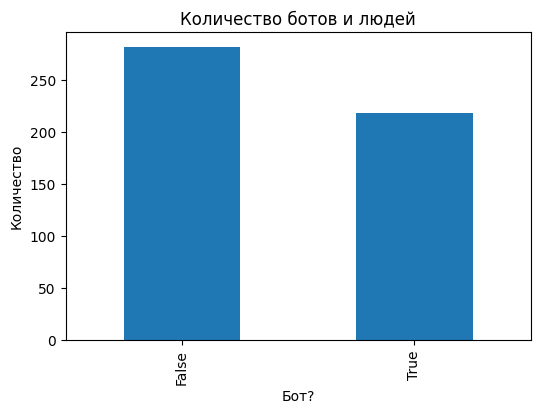

In [ ]:
plt.figure(figsize=(6,4))
data["is_bot_flag"].value_counts().plot(kind="bar")
plt.title("Количество ботов и людей")
plt.xlabel("Бот?")
plt.ylabel("Количество")
plt.show()

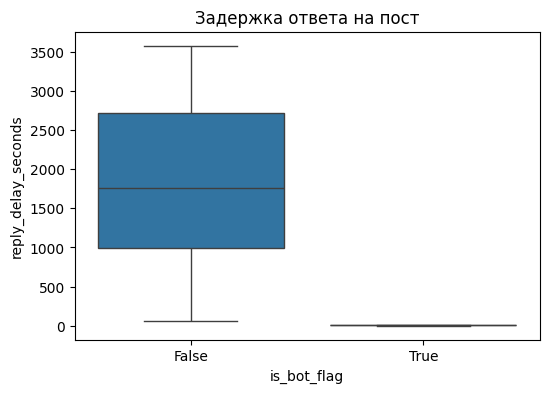

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="is_bot_flag", y="reply_delay_seconds", data=data2)
plt.title("Задержка ответа на пост")
plt.show()

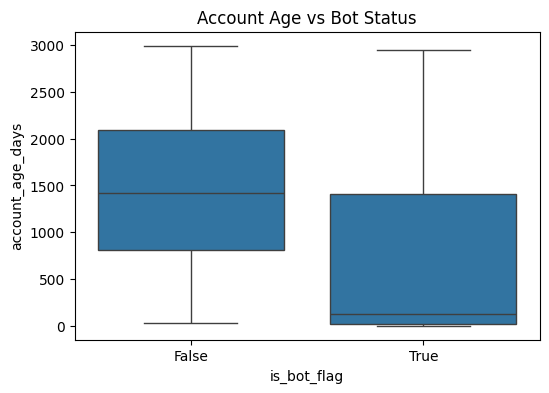

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(x="is_bot_flag", y="account_age_days", data=data2)
plt.title("Возраста аккаунтов ботов и людей")
plt.show()

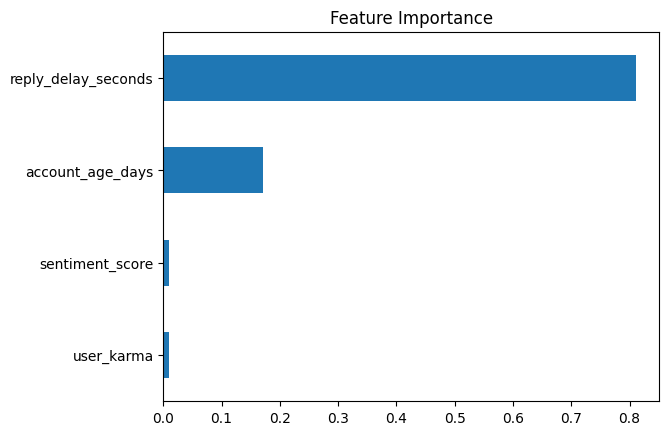

In [ ]:
importances = pd.Series(model.feature_importances_, index=features)
importances.sort_values().plot(kind="barh")
plt.title("Влияние факторов на обучение")
plt.show()

In [16]:
account_age_days = int(input("Enter account age in days: "))
user_karma = int(input("Enter user karma: "))
reply_delay_seconds = int(input("Enter reply delay in seconds: "))
sentiment_score = float(input("Enter sentiment score: "))

# Важно: порядок столбцов совпадает с model.feature_names_in_
input_data = pd.DataFrame([[account_age_days, user_karma, reply_delay_seconds, sentiment_score]],
                          columns=model.feature_names_in_)

prediction = model.predict(input_data)
print(f"Prediction: {prediction}")

Prediction: [ True]
